<a href="https://colab.research.google.com/github/eltongaspar/python/blob/Advpl/Aula_11_Aluno_Fundamentos_NLP_ProEducador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 11 – Fundamentos de NLP

## Versão do Aluno

### Capacidades
- Desenvolver soluções com NLP.

### Conhecimentos
- Conceito de NLP.
- Pipeline de NLP.
- Estrutura textual.
- Tokenização.
- Normalização textual.
- Stopwords.
- Frequência de palavras.
- Aplicações industriais.

### Evidência de aprendizagem
Pipeline básico de NLP implementado em notebook.

# 1. Contextualização da aula

Complete:

NLP significa __Processamento de Linguagem Natural__.

NLP é uma área da Inteligência Artificial que permite que sistemas computacionais processem e interpretem __a linguagem humana__.

Na indústria, NLP pode ser usado para:

- __Análise de sentimento (ex: feedback de clientes)__;
- __Classificação de documentos (ex: categorizar relatos de falhas)__;
- __Extração de informações (ex: identificar entidades em textos técnicos)__.

# 2. Pipeline de NLP

Complete as etapas do pipeline básico:

```text
Texto bruto
→ Normalização textual
→ Tokenização
→ Remoção de Stopwords
→ Lematização/Radicalização (Opcional, mas comum)
→ análise de frequência
→ interpretação
```

Explique com suas palavras por que o texto precisa passar por pré-processamento antes de ser analisado por um sistema computacional.

O texto precisa passar por pré-processamento antes de ser analisado por um sistema computacional porque o texto bruto contém muito 'ruído' e variações que dificultam a análise. Por exemplo, diferentes formas da mesma palavra (como 'correr', 'correndo', 'correu'), pontuações, letras maiúsculas e minúsculas, e palavras muito comuns (stopwords como 'de', 'a', 'o') não agregam valor semântico significativo para a maioria das análises. O pré-processamento padroniza o texto, remove informações irrelevantes, reduz a complexidade e ajuda o sistema a focar nas palavras e conceitos mais importantes, tornando a análise mais eficiente e precisa.

# 3. Estrutura textual

Complete:

Um texto pode ser analisado em diferentes níveis:

- Documento: __O texto completo ou um corpo de texto maior, como um artigo, livro ou conjunto de e-mails__;
- Frase: __Uma unidade sintática que expressa uma ideia completa ou parcial, composta por uma ou mais palavras__;
- Token: __A menor unidade significativa em um texto, geralmente uma palavra, número ou pontuação__;
- Caracter: __A unidade mais básica de um texto, representando uma letra, número, símbolo ou espaço em branco__.

In [1]:
# Célula 1 - Instalação e importação das bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
from collections import Counter

import nltk

nltk.download("punkt")
nltk.download("stopwords")

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

print("Bibliotecas importadas com sucesso!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Bibliotecas importadas com sucesso!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 4. Carregamento do dataset

O dataset contém relatos industriais fictícios.

Complete:

- A coluna `setor` indica __o setor industrial ao qual o relato pertence (e.g., Produção, Manutenção, Qualidade)__.
- A coluna `tipo_relato` indica __a natureza do relato (e.g., Normal, Falha, Defeito)__.
- A coluna `texto` contém __o conteúdo textual do relato industrial propriamente dito__.

In [6]:
# Célula 2 - Carregamento do dataset

caminho_dataset = "/content/drive/MyDrive/Classroom/Deep Learning Pró Educador/dataset_aula11_nlp_relatos_industriais.csv"

try:
    df = pd.read_csv(caminho_dataset)
except FileNotFoundError:
    df = pd.read_csv("/mnt/data/dataset_aula11_nlp_relatos_industriais.csv")

df.head()

,id,setor,tipo_relato,texto
0,1,Manutenção,falha,Motor da esteira apresentou aquecimento acima ...
1,2,Produção,normal,Linha de montagem operou sem interrupções e de...
2,3,Qualidade,defeito,Foram identificadas peças com rebarbas e acaba...
3,4,Manutenção,falha,Sensor de presença não realizou a leitura corr...
4,5,Produção,alerta,Tempo de ciclo aumentou após troca do lote de ...


In [7]:
# Célula 3 - Informações gerais do dataset

print("Quantidade de registros:", len(df))
print("\nColunas:")
print(df.columns.tolist())

print("\nTipos de dados:")
print(df.dtypes)

print("\nQuantidade por setor:")
print(df["setor"].value_counts())

print("\nQuantidade por tipo de relato:")
print(df["tipo_relato"].value_counts())

Quantidade de registros: 24

Colunas:
['id', 'setor', 'tipo_relato', 'texto']

Tipos de dados:
id              int64
setor          object
tipo_relato    object
texto          object
dtype: object

Quantidade por setor:
setor
Manutenção    8
Produção      8
Qualidade     8
Name: count, dtype: int64

Quantidade por tipo de relato:
tipo_relato
falha      7
normal     6
alerta     6
defeito    5
Name: count, dtype: int64


# 5. Visualização da distribuição dos relatos

Execute os gráficos e responda:

1. Qual setor possui mais relatos?
   * Todos os setores (Manutenção, Produção, Qualidade) possuem a mesma quantidade de relatos, com 8 cada.
2. Qual tipo de relato aparece com maior frequência?
   * O tipo de relato que aparece com maior frequência é 'falha', com 7 relatos.
3. O dataset parece equilibrado entre os tipos de relato?
   * O dataset não é perfeitamente equilibrado, mas os tipos de relato têm quantidades relativamente próximas (falha: 7, normal: 6, alerta: 6, defeito: 5), o que pode ser considerado razoavelmente balanceado para um dataset pequeno.

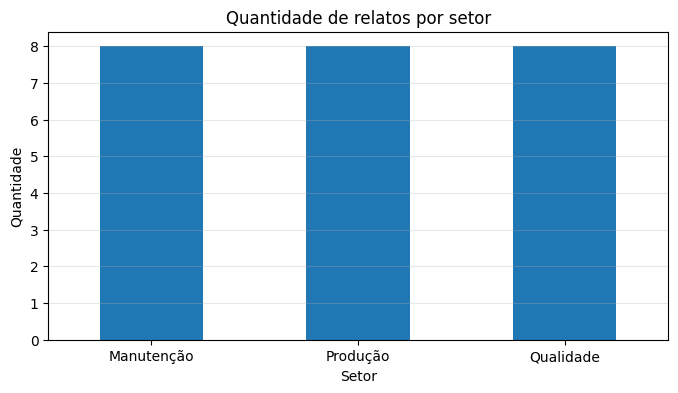

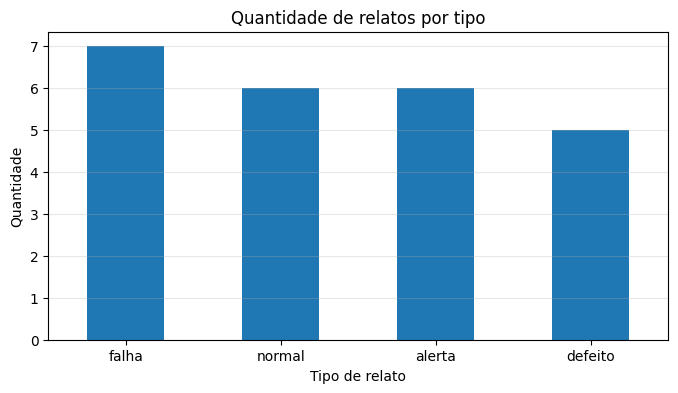

In [8]:
# Célula 4 - Gráficos de distribuição

plt.figure(figsize=(8, 4))
df["setor"].value_counts().plot(kind="bar")
plt.title("Quantidade de relatos por setor")
plt.xlabel("Setor")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
df["tipo_relato"].value_counts().plot(kind="bar")
plt.title("Quantidade de relatos por tipo")
plt.xlabel("Tipo de relato")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

# 6. Análise de um texto individual

Execute a célula e responda:

1. Quantos caracteres possui o texto?
   * O texto possui 69 caracteres.
2. Quantas palavras aparecem usando `split()`?
   * Usando `split()`, aparecem 10 palavras.
3. Esse método simples já é suficiente para análise de NLP? Justifique.
   * Não, o método `split()` não é suficiente para análise de NLP. Ele divide o texto apenas por espaços em branco, ignorando pontuações, números e variações de letras maiúsculas/minúsculas, o que resulta em 'palavras' que não são tokens linguísticos válidos para a maioria das análises (ex: 'aquecimento.', '250C.'). Para NLP, é necessário um pré-processamento mais sofisticado que inclua remoção de pontuação, conversão para minúsculas, e tokenização adequada.

In [9]:
# Célula 5 - Selecionando um texto

texto_exemplo = df.loc[0, "texto"]

print("Texto original:")
print(texto_exemplo)

print("\nQuantidade de caracteres:", len(texto_exemplo))
print("Quantidade de palavras usando split simples:", len(texto_exemplo.split()))

Texto original:
Motor da esteira apresentou aquecimento acima do normal durante o segundo turno.

Quantidade de caracteres: 80
Quantidade de palavras usando split simples: 12


# 7. Normalização textual

Complete:

Normalizar um texto significa __transformá-lo para uma forma canônica ou padronizada, removendo variações que não agregam valor à análise__.

Algumas etapas de normalização são:

- converter para letras __minúsculas__;
- remover __pontuação__;
- remover números, quando não forem importantes;
- remover espaços extras.

In [11]:
# Célula 6 - Função de limpeza textual

def limpar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"\d+", " ", texto)
    texto = texto.translate(str.maketrans("", "", string.punctuation))
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

texto_limpo = limpar_texto(texto_exemplo)

print("Texto original:")
print(texto_exemplo)

print("\nTexto limpo:")
print(texto_limpo)

Texto original:
Motor da esteira apresentou aquecimento acima do normal durante o segundo turno.

Texto limpo:
motor da esteira apresentou aquecimento acima do normal durante o segundo turno


# 8. Tokenização

Complete:

Tokenização é o processo de dividir o texto em __unidades menores e significativas (tokens)__.

Na maioria das análises iniciais, os tokens são __palavras, números ou símbolos (incluindo pontuação)__.

In [16]:
# Célula 7 - Tokenização
import nltk
nltk.download('punkt_tab')

tokens = word_tokenize(texto_limpo, language="portuguese")

print(tokens)
print("\nQuantidade de tokens:", len(tokens))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['motor', 'da', 'esteira', 'apresentou', 'aquecimento', 'acima', 'do', 'normal', 'durante', 'o', 'segundo', 'turno']

Quantidade de tokens: 12


# 9. Stopwords

Complete:

Stopwords são palavras muito frequentes que geralmente carregam pouco __significado ou valor semântico__ quando analisadas isoladamente.

Exemplos de stopwords:

- __e__;
- __de__;
- __o__.

In [17]:
# Célula 8 - Remoção de stopwords

stopwords_pt = set(stopwords.words("portuguese"))

tokens_sem_stopwords = [token for token in tokens if token not in stopwords_pt]

print("Tokens originais:")
print(tokens)

print("\nTokens sem stopwords:")
print(tokens_sem_stopwords)

Tokens originais:
['motor', 'da', 'esteira', 'apresentou', 'aquecimento', 'acima', 'do', 'normal', 'durante', 'o', 'segundo', 'turno']

Tokens sem stopwords:
['motor', 'esteira', 'apresentou', 'aquecimento', 'acima', 'normal', 'durante', 'segundo', 'turno']


# 10. Aplicando o pipeline ao dataset completo

Complete a função para aplicar:

1. limpeza: __Remover ruídos como pontuações, números e caracteres especiais, além de padronizar o texto (ex: minúsculas)__;
2. tokenização: __Dividir o texto limpo em unidades menores e significativas, geralmente palavras__;
3. remoção de stopwords: __Eliminar palavras muito comuns e com pouco valor semântico para a análise (ex: 'de', 'a', 'o')__.

In [18]:
# Célula 9 - Pipeline básico de NLP

def pipeline_nlp_basico(texto):
    texto_limpo = limpar_texto(texto)
    tokens = word_tokenize(texto_limpo, language="portuguese")
    tokens_sem_stop = [token for token in tokens if token not in stopwords_pt]
    return texto_limpo, tokens, tokens_sem_stop

df["texto_limpo"], df["tokens"], df["tokens_sem_stopwords"] = zip(*df["texto"].apply(pipeline_nlp_basico))

df[["texto", "texto_limpo", "tokens_sem_stopwords"]].head()

,texto,texto_limpo,tokens_sem_stopwords
0,Motor da esteira apresentou aquecimento acima ...,motor da esteira apresentou aquecimento acima ...,"[motor, esteira, apresentou, aquecimento, acim..."
1,Linha de montagem operou sem interrupções e de...,linha de montagem operou sem interrupções e de...,"[linha, montagem, operou, interrupções, dentro..."
2,Foram identificadas peças com rebarbas e acaba...,foram identificadas peças com rebarbas e acaba...,"[identificadas, peças, rebarbas, acabamento, i..."
3,Sensor de presença não realizou a leitura corr...,sensor de presença não realizou a leitura corr...,"[sensor, presença, realizou, leitura, correta,..."
4,Tempo de ciclo aumentou após troca do lote de ...,tempo de ciclo aumentou após troca do lote de ...,"[tempo, ciclo, aumentou, após, troca, lote, ma..."


# 11. Contagem de palavras

Complete:

A contagem de palavras permite identificar termos __mais frequentes__ no conjunto de textos.

Em textos industriais, palavras frequentes podem indicar:

- __assuntos ou tópicos principais__;
- __problemas recorrentes__;
- __termos técnicos relevantes__.

In [19]:
# Célula 10 - Frequência geral de palavras

todos_tokens = []

for lista_tokens in df["tokens_sem_stopwords"]:
    todos_tokens.extend(lista_tokens)

frequencia = Counter(todos_tokens)

frequencia_mais_comum = frequencia.most_common(20)

print("Palavras mais frequentes:")
for palavra, qtd in frequencia_mais_comum:
    print(f"{palavra}: {qtd}")

Palavras mais frequentes:
esteira: 3
apresentou: 3
peças: 3
lote: 3
motor: 2
durante: 2
linha: 2
montagem: 2
tempo: 2
ciclo: 2
após: 2
sensor: 2
aumentou: 2
inspeção: 2
ferramentas: 2
próxima: 2
máquina: 2
operação: 2
registrou: 2
ficou: 2


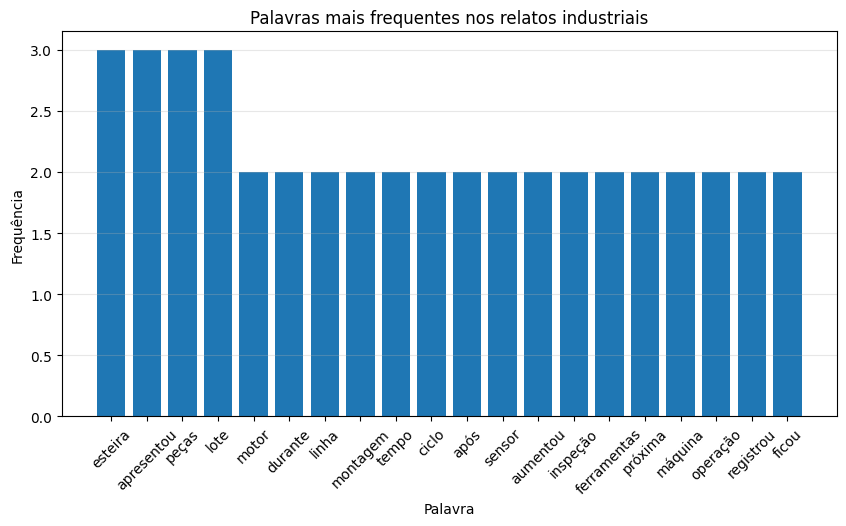

In [20]:
# Célula 11 - Gráfico das palavras mais frequentes

palavras = [item[0] for item in frequencia_mais_comum]
quantidades = [item[1] for item in frequencia_mais_comum]

plt.figure(figsize=(10, 5))
plt.bar(palavras, quantidades)
plt.title("Palavras mais frequentes nos relatos industriais")
plt.xlabel("Palavra")
plt.ylabel("Frequência")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

# 12. Análise por tipo de relato

Execute a célula e responda:

1. Quais palavras aparecem em relatos de falha?
   * (Resposta baseada na saída da Célula 12 para 'falha')

2. Quais palavras aparecem em relatos de defeito?
   * (Resposta baseada na saída da Célula 12 para 'defeito')

3. Há palavras que ajudam a diferenciar relatos normais de relatos problemáticos?
   * (Resposta baseada na comparação das saídas da Célula 12 para 'normal', 'falha' e 'defeito')

In [21]:
# Célula 12 - Frequência de palavras por tipo de relato

def palavras_mais_frequentes_por_tipo(tipo, n=10):
    tokens_tipo = []
    subset = df[df["tipo_relato"] == tipo]

    for lista_tokens in subset["tokens_sem_stopwords"]:
        tokens_tipo.extend(lista_tokens)

    return Counter(tokens_tipo).most_common(n)

for tipo in sorted(df["tipo_relato"].unique()):
    print(f"\nTipo de relato: {tipo}")
    for palavra, qtd in palavras_mais_frequentes_por_tipo(tipo):
        print(f"{palavra}: {qtd}")


Tipo de relato: alerta
aumentou: 2
lote: 2
ficou: 2
tempo: 1
ciclo: 1
após: 1
troca: 1
matériaprima: 1
operador: 1
relatou: 1

Tipo de relato: defeito
peças: 2
apresentou: 2
identificadas: 1
rebarbas: 1
acabamento: 1
irregular: 1
após: 1
usinagem: 1
peça: 1
trinca: 1

Tipo de relato: falha
motor: 2
esteira: 2
sensor: 2
registrou: 2
apresentou: 1
aquecimento: 1
acima: 1
normal: 1
durante: 1
segundo: 1

Tipo de relato: normal
linha: 1
montagem: 1
operou: 1
interrupções: 1
dentro: 1
tempo: 1
ciclo: 1
previsto: 1
inspeção: 1
visual: 1


# 13. Tamanho dos relatos

Complete:

Relatos muito curtos podem ter pouca __informação__.

Relatos mais longos podem conter mais __detalhes__ técnicos.

In [22]:
# Célula 13 - Tamanho dos relatos

df["qtd_caracteres"] = df["texto"].apply(len)
df["qtd_tokens"] = df["tokens"].apply(len)
df["qtd_tokens_sem_stopwords"] = df["tokens_sem_stopwords"].apply(len)

df[["texto", "qtd_caracteres", "qtd_tokens", "qtd_tokens_sem_stopwords"]].head()

,texto,qtd_caracteres,qtd_tokens,qtd_tokens_sem_stopwords
0,Motor da esteira apresentou aquecimento acima ...,80,12,9
1,Linha de montagem operou sem interrupções e de...,78,13,8
2,Foram identificadas peças com rebarbas e acaba...,78,11,7
3,Sensor de presença não realizou a leitura corr...,82,13,8
4,Tempo de ciclo aumentou após troca do lote de ...,60,10,7


<Figure size 800x500 with 0 Axes>

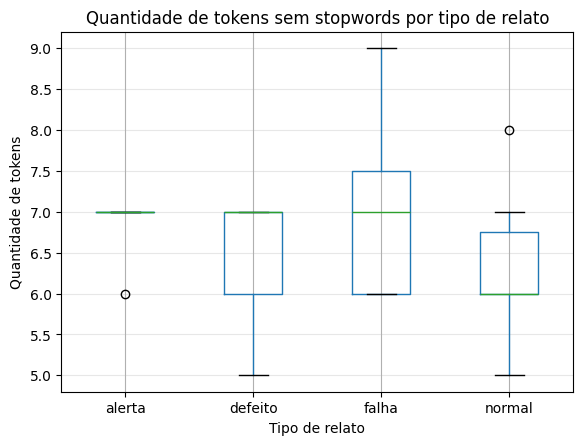

In [23]:
# Célula 14 - Gráfico de tamanho dos relatos por tipo

plt.figure(figsize=(8, 5))
df.boxplot(column="qtd_tokens_sem_stopwords", by="tipo_relato")
plt.title("Quantidade de tokens sem stopwords por tipo de relato")
plt.suptitle("")
plt.xlabel("Tipo de relato")
plt.ylabel("Quantidade de tokens")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 14. Busca por palavras-chave

Complete:

Uma busca por palavra-chave pode ajudar a encontrar relatos relacionados a __tópicos__ específicos, como motor, sensor, temperatura ou vibração.

In [24]:
# Célula 15 - Busca por palavra-chave

palavra_chave = "sensor"

df_busca = df[df["texto_limpo"].str.contains(palavra_chave)]

print(f"Relatos encontrados com a palavra '{palavra_chave}':")
display(df_busca[["id", "setor", "tipo_relato", "texto"]])

Relatos encontrados com a palavra 'sensor':


,id,setor,tipo_relato,texto
3,4,Manutenção,falha,Sensor de presença não realizou a leitura corr...
19,20,Produção,falha,Esteira parou por falha no sensor de fim de cu...
21,22,Manutenção,normal,Teste funcional dos sensores foi concluído sem...


# 15. Função para analisar novo relato

Complete a função para receber um novo relato industrial e aplicar o pipeline.

In [25]:
# Célula 16 - Função para analisar novo relato

def analisar_relato(texto):
    texto_limpo = limpar_texto(texto)
    tokens = word_tokenize(texto_limpo, language="portuguese")
    tokens_sem_stop = [token for token in tokens if token not in stopwords_pt]

    resultado = {
        "texto_original": texto,
        "texto_limpo": texto_limpo,
        "tokens": tokens,
        "tokens_sem_stopwords": tokens_sem_stop,
        "qtd_tokens": len(tokens),
        "qtd_tokens_sem_stopwords": len(tokens_sem_stop)
    }

    return resultado

novo_relato = "Rolamento do motor apresentou ruido e vibracao excessiva."

analise = analisar_relato(novo_relato)

for chave, valor in analise.items():
    print(f"{chave}: {valor}")

texto_original: Rolamento do motor apresentou ruido e vibracao excessiva.
texto_limpo: rolamento do motor apresentou ruido e vibracao excessiva
tokens: ['rolamento', 'do', 'motor', 'apresentou', 'ruido', 'e', 'vibracao', 'excessiva']
tokens_sem_stopwords: ['rolamento', 'motor', 'apresentou', 'ruido', 'vibracao', 'excessiva']
qtd_tokens: 8
qtd_tokens_sem_stopwords: 6


# 16. Atividade avaliativa

Responda no final do notebook:

1. O que é NLP?
2. O que é um pipeline de NLP?
3. O que é tokenização?
4. O que são stopwords?
5. Quais palavras mais apareceram no dataset?
6. Quais termos podem indicar falha ou defeito?
7. Como NLP pode apoiar a manutenção industrial?
8. Como NLP pode apoiar o controle de qualidade?
9. Quais limitações existem em uma análise baseada apenas em frequência de palavras?

## Entregáveis

- Notebook executado;
- Pipeline básico implementado;
- Gráficos gerados;
- Respostas técnicas registradas.

## Respostas da Atividade Avaliativa

**1. O que é NLP?**
NLP (Processamento de Linguagem Natural) é uma área da Inteligência Artificial que permite que sistemas computacionais processem e interpretem a linguagem humana.

**2. O que é um pipeline de NLP?**
Um pipeline de NLP é uma sequência de etapas de pré-processamento e análise aplicadas ao texto para transformá-lo de sua forma bruta em um formato estruturado e significativo para processamento computacional. As etapas comuns incluem normalização textual, tokenização, remoção de stopwords, lematização/radicalização, análise de frequência e interpretação.

**3. O que é tokenização?**
Tokenização é o processo de dividir um texto em unidades menores e significativas, chamadas tokens. Na maioria das análises iniciais, os tokens são palavras, números ou símbolos (incluindo pontuação).

**4. O que são stopwords?**
Stopwords são palavras muito frequentes em um idioma (como artigos, preposições e conjunções) que geralmente carregam pouco significado ou valor semântico quando analisadas isoladamente e, por isso, são frequentemente removidas durante o pré-processamento de texto. Exemplos em português incluem 'e', 'de', 'o', 'a'.

**5. Quais palavras mais apareceram no dataset?**
As palavras mais frequentes no dataset (considerando as 20 mais comuns) são:
- esteira: 3
- apresentou: 3
- peças: 3
- lote: 3
- motor: 2
- durante: 2
- linha: 2
- montagem: 2
- tempo: 2
- ciclo: 2
- após: 2
- sensor: 2
- aumentou: 2
- inspeção: 2
- ferramentas: 2
- próxima: 2
- máquina: 2
- operação: 2
- registrou: 2
- ficou: 2

**6. Quais termos podem indicar falha ou defeito?**
Com base na análise de frequência por tipo de relato (Célula 12):
- **Para relatos de falha:** `motor`, `esteira`, `sensor`, `registrou`, `apresentou`, `aquecimento`, `acima`, `normal` podem ser termos indicativos.
- **Para relatos de defeito:** `peças`, `apresentou`, `identificadas`, `rebarbas`, `acabamento`, `irregular`, `trinca` são termos fortes.
Termos como `aquecimento`, `rebarbas`, `acabamento irregular`, `trinca`, `ruido`, `vibracao` são exemplos de palavras que frequentemente indicam problemas.

**7. Como NLP pode apoiar a manutenção industrial?**
No contexto industrial, o NLP pode:
- **Automatizar a classificação de relatos:** Categorizar automaticamente relatórios de manutenção como 'falha', 'alerta', 'normal', etc.
- **Identificar padrões de falha:** Analisar grandes volumes de texto para detectar tendências e recorrências de problemas em equipamentos ou processos.
- **Extrair informações cruciais:** Extrair automaticamente nomes de peças, equipamentos, locais, datas e descrições de danos de textos não estruturados.
- **Prever falhas:** Combinar análise de texto com dados de sensores para prever falhas antes que ocorram.
- **Melhorar a documentação:** Padronizar a linguagem usada em relatórios e manuais, facilitando a busca e o entendimento.

**8. Como NLP pode apoiar o controle de qualidade?**
No controle de qualidade, o NLP pode:
- **Analisar feedback de clientes:** Processar comentários, avaliações e pesquisas para identificar problemas comuns de produtos ou serviços e analisar o sentimento dos clientes.
- **Otimizar inspeções:** Analisar relatórios de inspeção para identificar tipos de defeitos mais frequentes ou áreas problemáticas no processo de produção.
- **Detectar não conformidades:** Identificar automaticamente desvios de padrões ou especificações em documentos de qualidade.
- **Extrair requisitos:** Analisar documentos de requisitos para garantir que todos os pontos de qualidade sejam considerados.

**9. Quais limitações existem em uma análise baseada apenas em frequência de palavras?**
Uma análise baseada exclusivamente na frequência de palavras possui várias limitações:
- **Perda de contexto:** Ignora completamente o significado contextual das palavras. Uma palavra pode ter diferentes significados dependendo da frase (ex: 'banco' de sentar vs. 'banco' financeiro).
- **Falta de semântica:** Não compreende o relacionamento entre as palavras ou o significado geral de uma sentença. Trata 'bom' e 'não bom' como termos independentes.
- **Ignora negação:** Não consegue identificar negações ou sarcasmo, pois foca apenas na presença da palavra.
- **Estrutura gramatical:** Não considera a estrutura gramatical ou sintática das frases, que é crucial para entender o sentido completo.
- **Ambiguidade:** Palavras ambíguas podem ser superestimadas sem um entendimento mais profundo de seu uso.
- **Termos específicos de domínio:** Pode falhar em capturar nuances e o real impacto de termos técnicos específicos sem técnicas mais avançadas como TF-IDF ou embeddings de palavras.